# HireSense — Job Market & Skill Demand Analyzer

## Project Overview

HireSense is a data analysis and machine learning project that analyzes job
postings to understand current job-market trends, in-demand skills,
job roles, employment types, experience levels, companies, and locations.

## Objectives

- Analyze job-market trends
- Identify the most demanded job roles
- Identify the most demanded skills
- Analyze job levels and employment types
- Analyze job locations and companies
- Understand relationships between job characteristics
- Build a machine learning model using relevant job-posting features
- Generate meaningful insights from the data

## Technologies Used

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## EDA (Exploratory Data Analysis)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("postings.csv")

In [3]:
df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,C# Software Engineer,E Tech Group,"West Chester, OH",https://www.linkedin.com/jobs/view/c%23-softwa...,2023-12-25,Covington,United States,Associate,Remote,"At E Tech Group, joining our team means joinin...","C#, .NET, WPF, ASP.NET MVC, WebAPI, C++, Progr..."
1,Software Implementation Engineer,Kardex,"Cincinnati, OH",https://www.linkedin.com/jobs/view/software-im...,2023-12-25,Covington,United States,Associate,Remote,Kardex Remstar is looking for a\nSoftware Impl...,"Software Implementation, Software Testing, Sof..."
2,"Senior Software Engineer, Back End (Go, AWS, J...",Jobs for Humanity,"Chattanooga, TN",https://www.linkedin.com/jobs/view/senior-soft...,2023-12-25,Chattanooga,United States,Mid senior,Onsite,Company Description\nJobs for Humanity is part...,"Java, Python, SQL, Node.js, Go, Scala, AWS, GC..."
3,"Senior Manager, Software Engineering, Full Stack",Jobs for Humanity,"Chattanooga, TN",https://www.linkedin.com/jobs/view/senior-mana...,2023-12-25,Chattanooga,United States,Mid senior,Onsite,Company Description\nJobs for Humanity is part...,"JavaScript, Java, TypeScript, SQL, Python, Go,..."
4,"Lead Software Engineer, Full Stack(JavaScript/...",Jobs for Humanity,"Chattanooga, TN",https://www.linkedin.com/jobs/view/lead-softwa...,2023-12-25,Chattanooga,United States,Mid senior,Onsite,Company Description\nJobs for Humanity is part...,"JavaScript, Java, AWS, Vue.js, HTML/CSS, TypeS..."


In [4]:
df.shape

(9380, 11)

In [5]:
df.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   job_title       9380 non-null   str  
 1   company         9380 non-null   str  
 2   job_location    9380 non-null   str  
 3   job_link        9380 non-null   str  
 4   first_seen      9380 non-null   str  
 5   search_city     9380 non-null   str  
 6   search_country  9380 non-null   str  
 7   job level       9380 non-null   str  
 8   job_type        9380 non-null   str  
 9   job_summary     9376 non-null   str  
 10  job_skills      9367 non-null   str  
dtypes: str(11)
memory usage: 40.3 MB


In [7]:
df.isnull().sum()

job_title          0
company            0
job_location       0
job_link           0
first_seen         0
search_city        0
search_country     0
job level          0
job_type           0
job_summary        4
job_skills        13
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe().T

,count,unique,top,freq
job_title,9380,3870,Senior Software Engineer,794
company,9380,3373,Jobs for Humanity,681
job_location,9380,1618,"San Francisco, CA",133
job_link,9380,9380,https://www.linkedin.com/jobs/view/c%23-softwa...,1
first_seen,9380,1,2023-12-25,9380
search_city,9380,709,Novato,92
search_country,9380,4,United States,7335
job level,9380,2,Mid senior,8101
job_type,9380,3,Onsite,4316
job_summary,9376,7763,"For more than 50 years, NISC has worked to dev...",62


In [10]:
df.nunique()

job_title         3870
company           3373
job_location      1618
job_link          9380
first_seen           1
search_city        709
search_country       4
job level            2
job_type             3
job_summary       7763
job_skills        9340
dtype: int64

In [11]:
df["job_title"].nunique()

3870

In [12]:
df["job_title"].value_counts().head(15)

job_title
Senior Software Engineer                                            794
Software Engineer                                                   588
Software Developer                                                  178
Senior Software Developer                                           145
Embedded Software Engineer                                          118
Sr. Software Engineer                                               113
Senior Embedded Software Engineer                                    98
Lead Software Engineer                                               77
Java Software Engineer                                               76
Software Engineer III                                                72
Principal Software Engineer                                          62
Software Developer III (Senior Software Engineer)                    62
Staff Software Engineer                                              58
Senior Software Engineer - Embedded & Desktop Linux Op

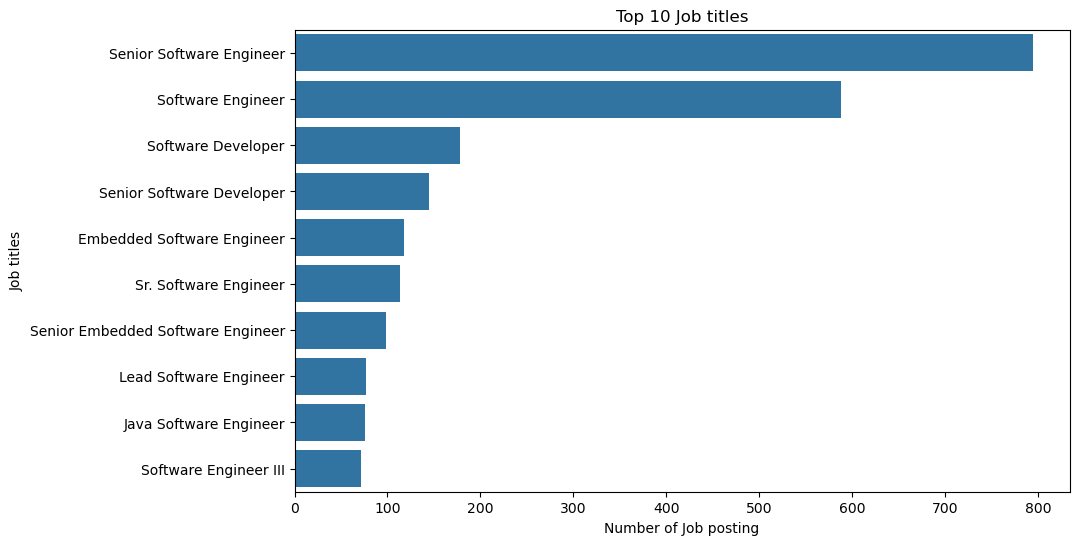

In [13]:
plt.figure(figsize=(10,6))

top_jobs = df["job_title"].value_counts().head(10)
sns.barplot(x= top_jobs.values, y= top_jobs.index)

plt.title("Top 10 Job titles")
plt.xlabel("Number of Job posting")
plt.ylabel("Job titles")

plt.show()

In [14]:
df["job level"].value_counts()

job level
Mid senior    8101
Associate     1279
Name: count, dtype: int64

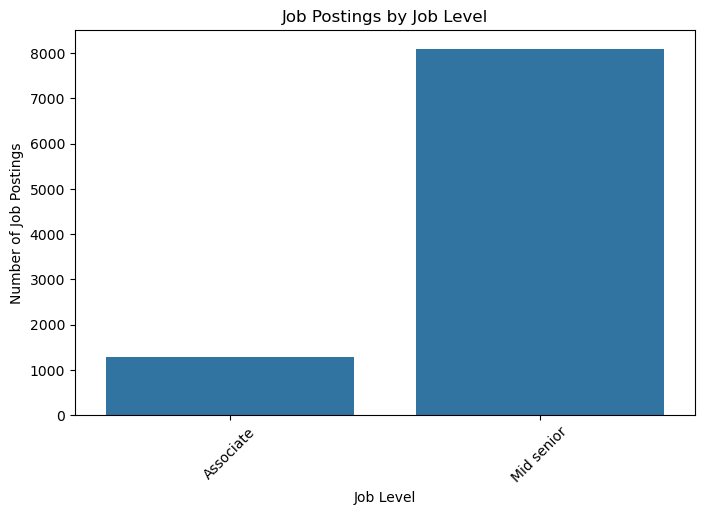

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data= df, x= "job level")

plt.title("Job Postings by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

plt.show()

In [16]:
df["job_type"].value_counts()

job_type
Onsite    4316
Hybrid    2745
Remote    2319
Name: count, dtype: int64

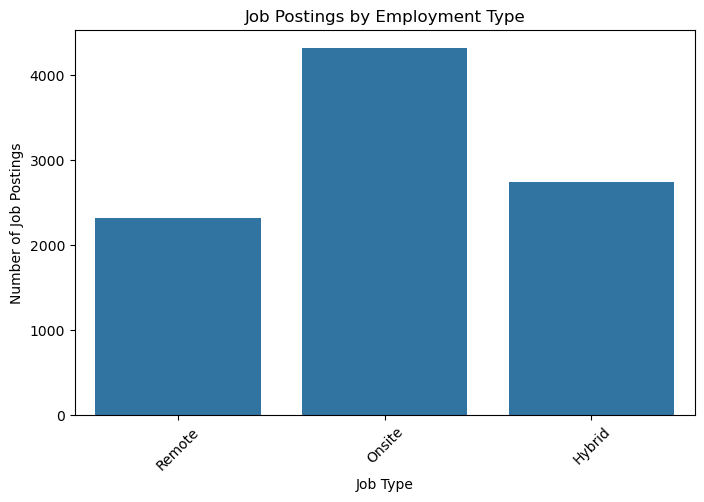

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(data= df, x= "job_type")

plt.title("Job Postings by Employment Type")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation= 45)

plt.show()

In [18]:
top_locations = df["job_location"].value_counts().head(10)
top_locations

job_location
San Francisco, CA                  133
London, England, United Kingdom    104
New York, NY                        98
United States                       82
Boston, MA                          81
Atlanta, GA                         78
Chicago, IL                         77
Austin, TX                          77
San Diego, CA                       77
Toronto, Ontario, Canada            76
Name: count, dtype: int64

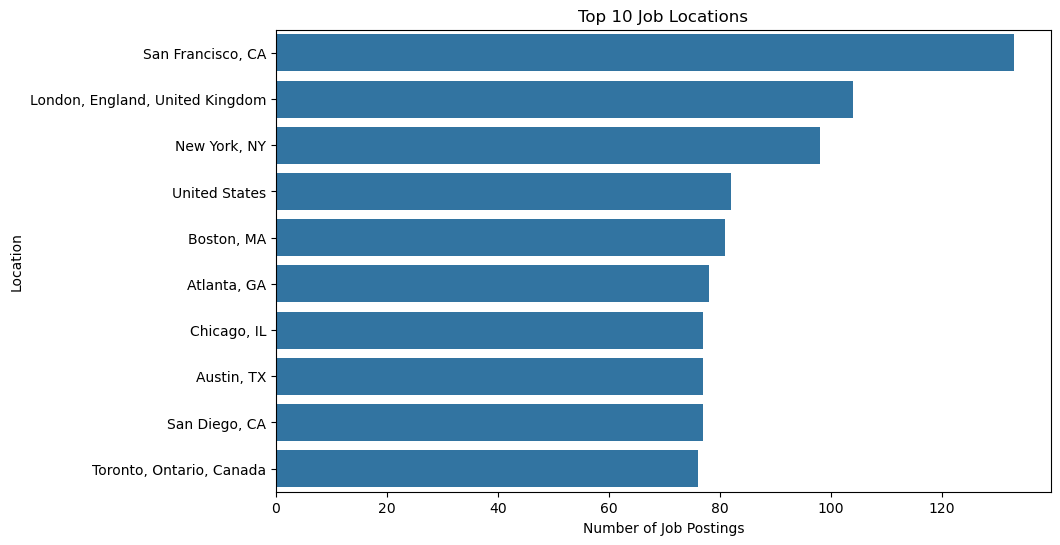

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(x= top_locations.values, y= top_locations.index)

plt.title("Top 10 Job Locations")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")

plt.show()

In [20]:
df["company"].nunique()

3373

In [21]:
top_companies = df["company"].value_counts().head(10)
top_companies

company
Jobs for Humanity                          681
Canonical                                  289
Recruiting from Scratch                    201
Affirm                                     137
ClearanceJobs                              110
IP Recruiter Group                          99
Northrop Grumman                            97
Get It Recruit - Information Technology     78
Energy Jobline                              71
Trimble Inc.                                68
Name: count, dtype: int64

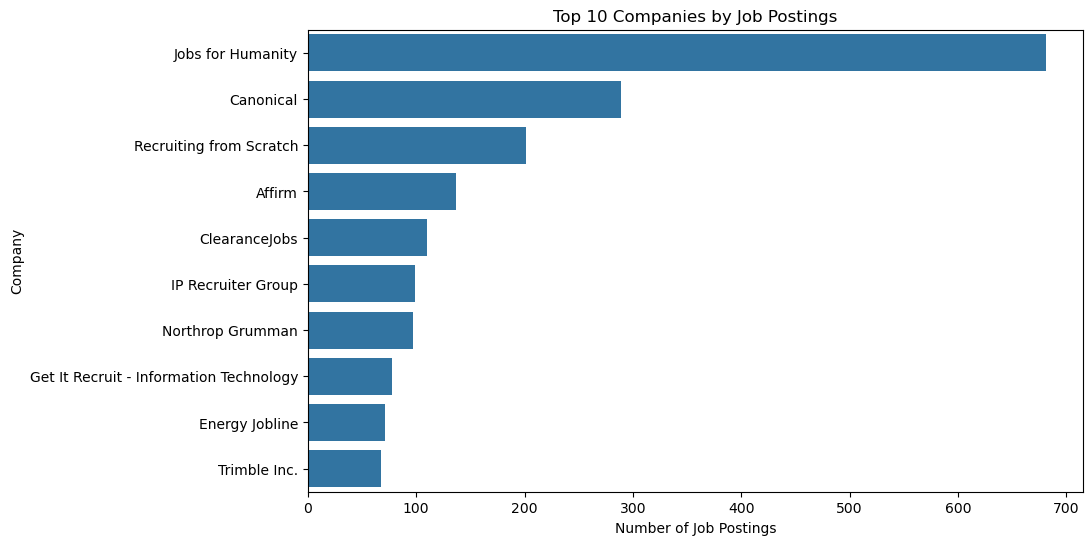

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(x= top_companies.values, y= top_companies.index)

plt.title("Top 10 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.show()

In [23]:
df["job_skills"].dropna().head(10)

0    C#, .NET, WPF, ASP.NET MVC, WebAPI, C++, Progr...
1    Software Implementation, Software Testing, Sof...
2    Java, Python, SQL, Node.js, Go, Scala, AWS, GC...
3    JavaScript, Java, TypeScript, SQL, Python, Go,...
4    JavaScript, Java, AWS, Vue.js, HTML/CSS, TypeS...
5    Application design, Analysis, Programming, Tes...
6    Java, Python, Angular, React, JavaScript, AWS,...
7    Java, Python, Angular, React, JavaScript, HTML...
8    Linux, U Boot, Low level drivers, Board suppor...
9    Linux, UBoot, Low Level Drivers, Board Support...
Name: job_skills, dtype: str

In [24]:
df["job_skills"].dropna().iloc[0]

'C#, .NET, WPF, ASP.NET MVC, WebAPI, C++, Programmable Logic Controllers, SQL Server, ASP.net, HTML5, CSS, Javascript, Git, Unity Engine, Desktop app design, Web app design, Mobile app design, Database design'

In [25]:
df["skills_clean"] = df["job_skills"].str.lower().str.strip()

In [26]:
df[["job_skills", "skills_clean"]].head(10)

,job_skills,skills_clean
0,"C#, .NET, WPF, ASP.NET MVC, WebAPI, C++, Progr...","c#, .net, wpf, asp.net mvc, webapi, c++, progr..."
1,"Software Implementation, Software Testing, Sof...","software implementation, software testing, sof..."
2,"Java, Python, SQL, Node.js, Go, Scala, AWS, GC...","java, python, sql, node.js, go, scala, aws, gc..."
3,"JavaScript, Java, TypeScript, SQL, Python, Go,...","javascript, java, typescript, sql, python, go,..."
4,"JavaScript, Java, AWS, Vue.js, HTML/CSS, TypeS...","javascript, java, aws, vue.js, html/css, types..."
5,"Application design, Analysis, Programming, Tes...","application design, analysis, programming, tes..."
6,"Java, Python, Angular, React, JavaScript, AWS,...","java, python, angular, react, javascript, aws,..."
7,"Java, Python, Angular, React, JavaScript, HTML...","java, python, angular, react, javascript, html..."
8,"Linux, U Boot, Low level drivers, Board suppor...","linux, u boot, low level drivers, board suppor..."
9,"Linux, UBoot, Low Level Drivers, Board Support...","linux, uboot, low level drivers, board support..."


In [27]:
df["skills_list"] = df["skills_clean"].str.split(",")

In [28]:
df[["skills_clean", "skills_list"]].head()

,skills_clean,skills_list
0,"c#, .net, wpf, asp.net mvc, webapi, c++, progr...","[c#, .net, wpf, asp.net mvc, webapi, c++,..."
1,"software implementation, software testing, sof...","[software implementation, software testing, ..."
2,"java, python, sql, node.js, go, scala, aws, gc...","[java, python, sql, node.js, go, scala, ..."
3,"javascript, java, typescript, sql, python, go,...","[javascript, java, typescript, sql, python..."
4,"javascript, java, aws, vue.js, html/css, types...","[javascript, java, aws, vue.js, html/css, ..."


In [29]:
skills_df = df.explode("skills_list")

In [30]:
skills_df[["job_title", "skills_list"]].head(15)

,job_title,skills_list
0,C# Software Engineer,c#
0,C# Software Engineer,.net
0,C# Software Engineer,wpf
0,C# Software Engineer,asp.net mvc
0,C# Software Engineer,webapi
0,C# Software Engineer,c++
0,C# Software Engineer,programmable logic controllers
0,C# Software Engineer,sql server
0,C# Software Engineer,asp.net
0,C# Software Engineer,html5


In [31]:
skills_df["skills_list"] = skills_df["skills_list"].str.strip()

In [32]:
skills_df = skills_df[
    skills_df["skills_list"].notna() &
    (skills_df["skills_list"] != "")
]

In [33]:
top_skills = skills_df["skills_list"].value_counts().head(15)
top_skills

skills_list
python                  3554
java                    3181
javascript              2691
aws                     2569
sql                     2263
agile                   2059
git                     1803
c#                      1796
software engineering    1791
c++                     1690
kubernetes              1631
react                   1537
docker                  1535
software development    1492
typescript              1472
Name: count, dtype: int64

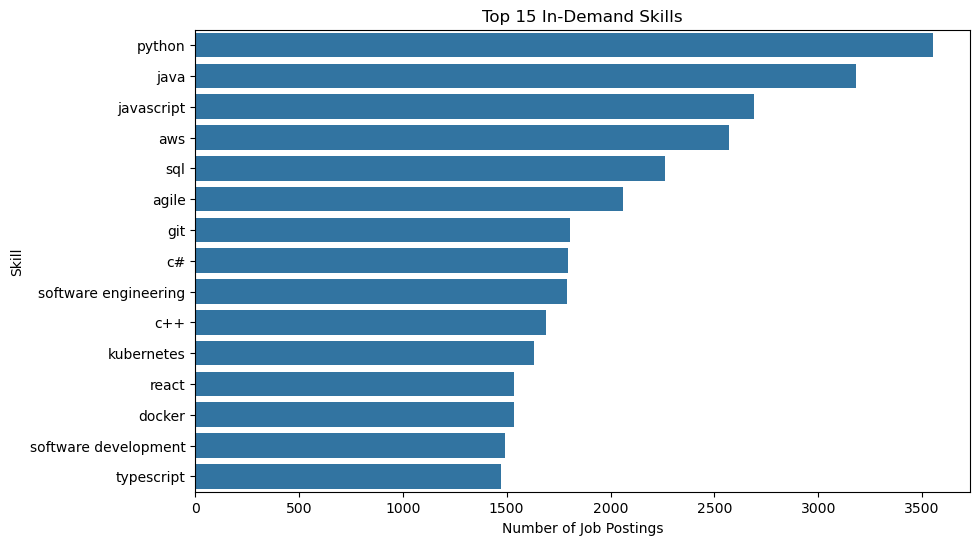

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(x= top_skills.values, y= top_skills.index)

plt.title("Top 15 In-Demand Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.show()

In [35]:
top_job_roles = df["job_title"].value_counts().head(10).index
top_job_roles

Index(['Senior Software Engineer', 'Software Engineer', 'Software Developer',
       'Senior Software Developer', 'Embedded Software Engineer',
       'Sr. Software Engineer', 'Senior Embedded Software Engineer',
       'Lead Software Engineer', 'Java Software Engineer',
       'Software Engineer III'],
      dtype='str', name='job_title')

In [36]:
role_skills_df = skills_df[skills_df["job_title"].isin(top_job_roles)].copy()

In [37]:
def get_top_skills(group):
    return group["skills_list"].value_counts().head(5)

In [38]:
top_role_skills = (
    role_skills_df
    .groupby("job_title")
    .apply(get_top_skills)
)

In [39]:
top_role_skills

job_title                          skills_list         
Embedded Software Engineer         c++                      47
                                   python                   34
                                   c                        32
                                   embedded systems         27
                                   linux                    23
Java Software Engineer             java                     71
                                   spring boot              27
                                   aws                      27
                                   microservices            23
                                   sql                      23
Lead Software Engineer             java                     32
                                   aws                      26
                                   python                   25
                                   sql                      22
                                   c#                       21

In [40]:
role = "Software Engineer"

skill_counts = role_skills_df[role_skills_df["job_title"] == role]["skills_list"].value_counts().head(10)
skill_counts

skills_list
python                  202
java                    177
c#                      169
javascript              160
git                     146
sql                     142
aws                     139
software engineering    132
c++                     130
react                   121
Name: count, dtype: int64

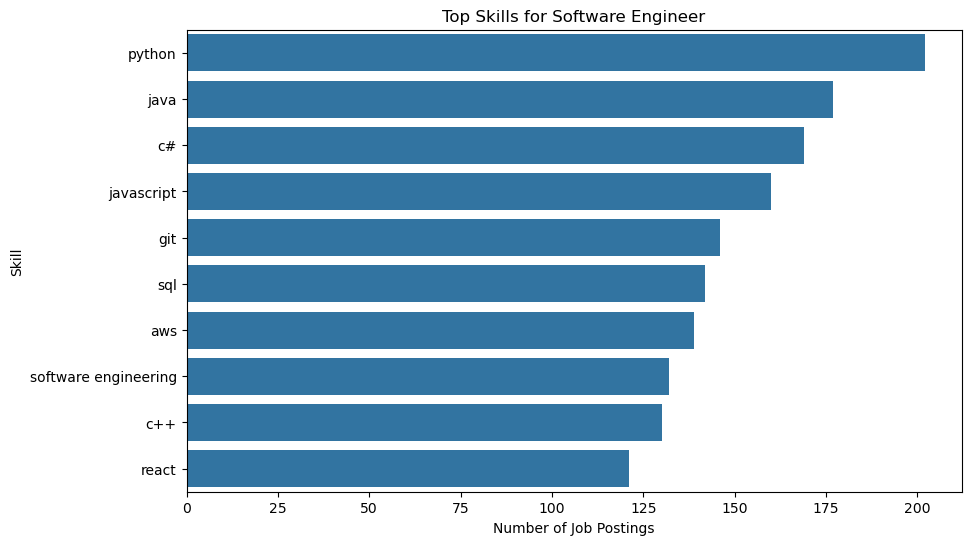

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(x= skill_counts.values, y= skill_counts.index)

plt.title(f"Top Skills for {role}")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.show()

In [42]:
role_skills_df = role_skills_df.reset_index(drop=True)

In [43]:
role_skills_df["job_title"] = role_skills_df["job_title"].astype(str).str.strip()
role_skills_df["skills_list"] = role_skills_df["skills_list"].astype(str).str.strip()

In [44]:
role_skill_matrix = pd.crosstab(
    role_skills_df["job_title"],
    role_skills_df["skills_list"]
)

In [45]:
role_skill_matrix.head()

skills_list,.net,.net 2,.net 4.x,.net 5 +,.net 5/6+,.net 6,.net 6+,.net 6.0,.net 7,.net 7+,...,zapier,zeek,zend,zephyr,zeromq,zigbee,zoom,zustand,前端,后端
job_title,,,,,,,,,,,,,,,,,,,,,
Embedded Software Engineer,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,0,0,0
Java Software Engineer,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Lead Software Engineer,9,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Senior Embedded Software Engineer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,3,0,1,0,0,0,0
Senior Software Developer,36,0,0,0,0,0,0,0,0,0,...,0,1,2,0,0,0,0,1,0,0


In [46]:
top_skills_list = skills_df["skills_list"].value_counts().head(10).index

role_skill_matrix = role_skill_matrix[
    [skill for skill in top_skills_list if skill in role_skill_matrix.columns]
]

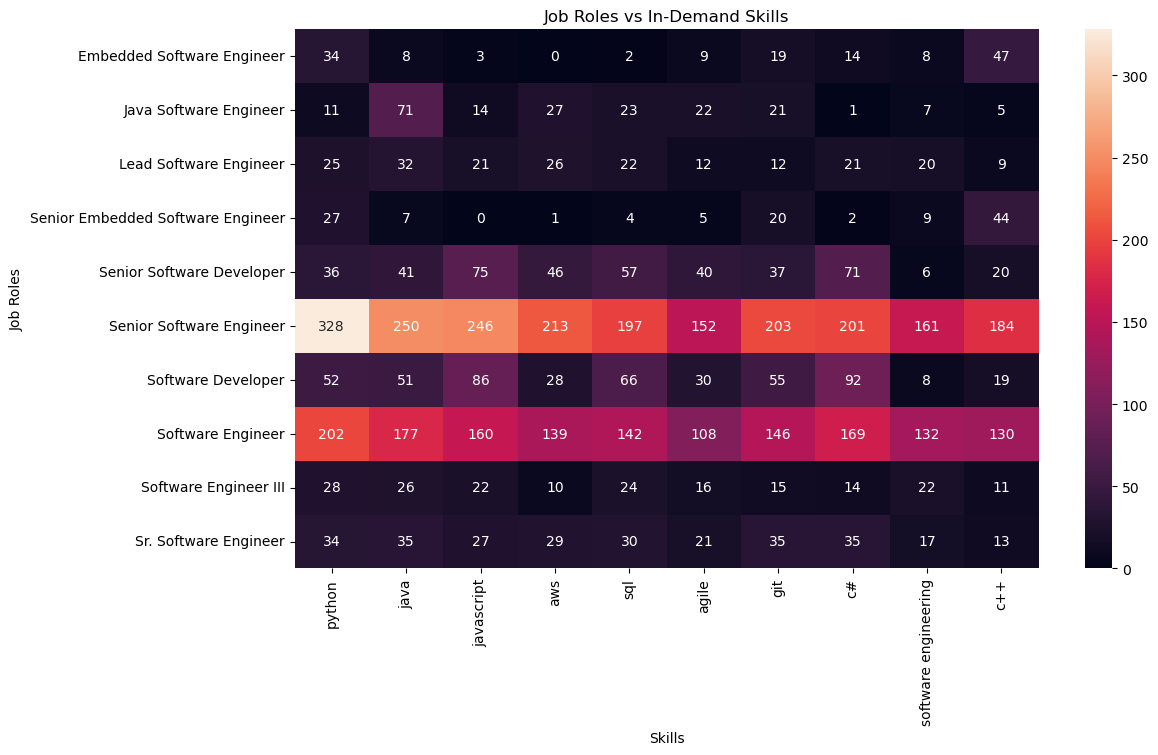

In [47]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    role_skill_matrix,
    annot=True,
    fmt="d"
)

plt.title("Job Roles vs In-Demand Skills")
plt.xlabel("Skills")
plt.ylabel("Job Roles")

plt.show()

In [48]:
def categorize_job(title):
    title = str(title).lower().strip()

    if any(word in title for word in [
        "cybersecurity", "cyber security", "security engineer",
        "security analyst", "information security", "application security"
    ]):
        return "Cybersecurity"

    elif any(word in title for word in [
        "machine learning", "ml engineer", "artificial intelligence",
        "ai engineer", "ai developer", "deep learning",
        "ai compiler", "ai software"
    ]):
        return "AI / Machine Learning"

    elif any(word in title for word in [
        "data scientist", "data science", "data analyst",
        "data analytics", "analytics engineer", "business analyst"
    ]):
        return "Data Science / Analytics"

    elif any(word in title for word in [
        "data engineer", "data engineering", "data pipeline",
        "data platform", "data warehouse", "data infrastructure",
        "etl developer", "etl engineer"
    ]):
        return "Data Engineering"

    elif any(word in title for word in [
        "devops", "cloud engineer", "cloud developer",
        "site reliability", "sre", "platform engineer"
    ]):
        return "DevOps / Cloud"

    elif any(word in title for word in [
        "qa engineer", "quality assurance", "test engineer",
        "software tester", "automation tester", "test automation",
        "quality engineer", "sdet", "software test"
    ]):
        return "QA / Testing"

    elif any(word in title for word in [
        "android", "ios", "mobile developer",
        "mobile engineer", "mobile application",
        "react native"
    ]):
        return "Mobile Development"

    elif any(word in title for word in [
        "frontend", "front-end", "front end",
        "ui developer", "web developer", "web engineer"
    ]):
        return "Frontend / Web"

    elif any(word in title for word in [
        "backend", "back-end", "back end"
    ]):
        return "Backend Development"

    elif any(word in title for word in [
        "embedded", "firmware", "embedded systems"
    ]):
        return "Embedded Systems"

    elif any(word in title for word in [
        "network engineer", "network administrator",
        "systems engineer", "system engineer",
        "systems administrator", "linux engineer",
        "networking"
    ]):
        return "Systems / Networking"

    elif any(word in title for word in [
        "hardware engineer", "electrical engineer",
        "electronics engineer"
    ]):
        return "Hardware / Electrical"

    elif any(word in title for word in [
        "software", "software engineer", "software developer",
        "software development", "software architect",
        "software design", "software integration",
        "software controls", "software verification",
        "software applications", "software support",
        "software technical", "software compliance",
        "application developer", "application engineer",
        "full stack", "full-stack"
    ]):
        return "Software Engineering"

    else:
        return "Other"

In [49]:
df["job_category"] = df["job_title"].apply(categorize_job)

In [50]:
df[["job_title", "job_category"]].head(20)

,job_title,job_category
0,C# Software Engineer,Software Engineering
1,Software Implementation Engineer,Software Engineering
2,"Senior Software Engineer, Back End (Go, AWS, J...",Backend Development
3,"Senior Manager, Software Engineering, Full Stack",Software Engineering
4,"Lead Software Engineer, Full Stack(JavaScript/...",Software Engineering
5,Sr. Software Engineer,Software Engineering
6,"Lead Software Engineer, Full Stack (Java, Pyth...",Software Engineering
7,"Lead Software Engineer, Full Stack (Java, Pyth...",Software Engineering
8,Senior Software Engineer,Software Engineering
9,Senior Software Engineer,Software Engineering


In [51]:
category_counts = df["job_category"].value_counts()
category_counts

job_category
Software Engineering        7360
Backend Development          605
Embedded Systems             558
Frontend / Web               245
QA / Testing                 227
Mobile Development           139
DevOps / Cloud                83
Systems / Networking          49
AI / Machine Learning         45
Data Engineering              32
Cybersecurity                 22
Data Science / Analytics      10
Hardware / Electrical          5
Name: count, dtype: int64

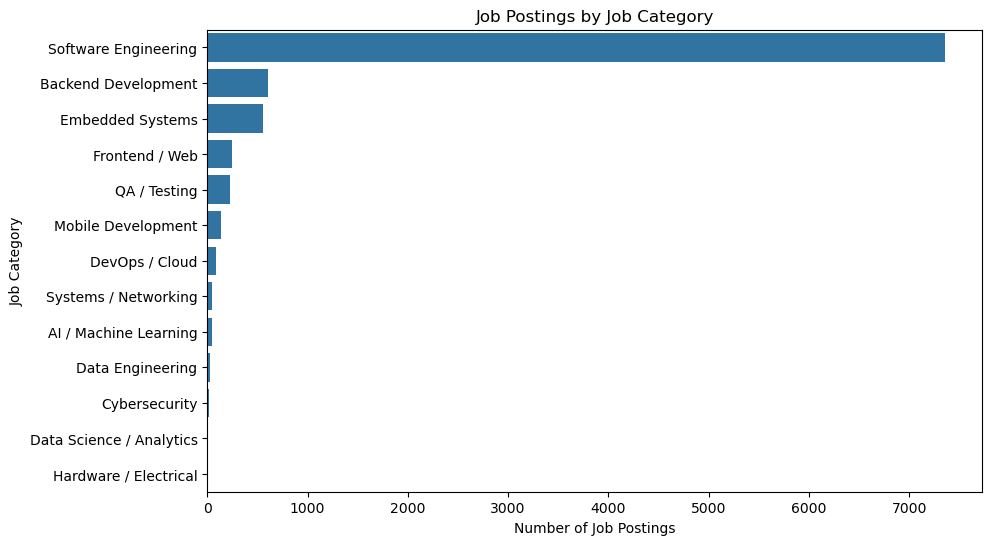

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(x= category_counts.values, y= category_counts.index)

plt.title("Job Postings by Job Category")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")

plt.show()

In [53]:
category_skills_df = df[["job_title", "job_category"]].merge(
    skills_df[["job_title", "skills_list"]],
    on="job_title",
    how="left"
)

In [54]:
category_skills_df.head()

,job_title,job_category,skills_list
0,C# Software Engineer,Software Engineering,c#
1,C# Software Engineer,Software Engineering,.net
2,C# Software Engineer,Software Engineering,wpf
3,C# Software Engineer,Software Engineering,asp.net mvc
4,C# Software Engineer,Software Engineering,webapi


In [55]:
category_skill_counts = (
    category_skills_df
    .groupby(["job_category", "skills_list"])
    .size()
    .reset_index(name="count")
)

category_skill_counts.head(20)

,job_category,skills_list,count
0,AI / Machine Learning,.net 5/6,4
1,AI / Machine Learning,a/b testing,10
2,AI / Machine Learning,aaa game development,1
3,AI / Machine Learning,advanced machine learning techniques (llm gene...,3
4,AI / Machine Learning,agile,2
5,AI / Machine Learning,ai,12
6,AI / Machine Learning,ai algorithms,18
7,AI / Machine Learning,ai infrastructure,12
8,AI / Machine Learning,ai pipelines,13
9,AI / Machine Learning,ai project implementation,6


In [56]:
top_skills_by_category = (
    category_skill_counts
    .sort_values(["job_category", "count"], ascending=[True, False])
    .groupby("job_category")
    .head(10)
)

top_skills_by_category

,job_category,skills_list,count
220,AI / Machine Learning,machine learning,74
315,AI / Machine Learning,python,72
53,AI / Machine Learning,c++,49
193,AI / Machine Learning,java,46
317,AI / Machine Learning,pytorch,40
...,...,...,...
34694,Systems / Networking,power electronics,432
34720,Systems / Networking,project management,408
34782,Systems / Networking,software design,408
34873,Systems / Networking,troubleshooting,368


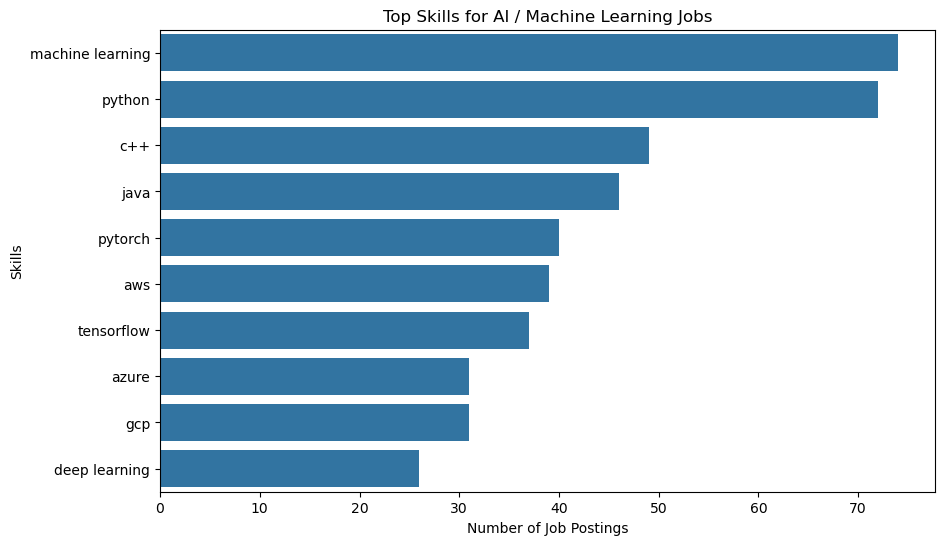

In [57]:
ai_ml_skills = top_skills_by_category[
    top_skills_by_category["job_category"] == "AI / Machine Learning"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ai_ml_skills,
    x="count",
    y="skills_list"
)

plt.title("Top Skills for AI / Machine Learning Jobs")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skills")

plt.show()

In [58]:
overall_top_skills = (
    category_skills_df["skills_list"]
    .value_counts()
    .head(15)
)

overall_top_skills

skills_list
python                  438346
java                    363156
javascript              346187
c#                      301856
aws                     297162
sql                     291242
git                     285786
c++                     250535
software engineering    229683
react                   227605
agile                   222613
kubernetes              219425
docker                  201763
linux                   194378
typescript              185687
Name: count, dtype: int64

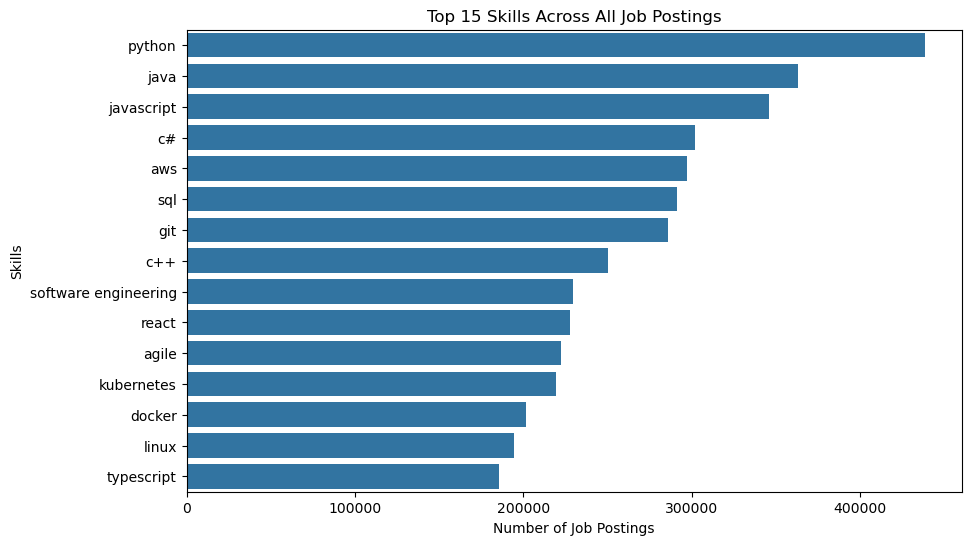

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=overall_top_skills.values,
    y=overall_top_skills.index
)

plt.title("Top 15 Skills Across All Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skills")

plt.show()

In [60]:
job_level_df = (
    df.groupby(["job_title", "job_category"])["skills_list"]
    .apply(lambda x: ", ".join(x.dropna().map(str).tolist()))
    .reset_index()
)

job_level_df.head()

,job_title,job_category,skills_list
0,"#738 - Systems Software Engineer - Up to $120,...",Software Engineering,"['linux administration', ' linux', ' javascrip..."
1,(C#/ Unity) AR/VR Software Engineer,Software Engineering,"['ar/vr', ' unity', ' c#', ' python', ' signal..."
2,(Remote) Mobile App Software Test Engineer,QA / Testing,"['ios', ' android', ' swift', ' objectivec', '..."
3,(Remote) Senior Software Engineer,Software Engineering,"['software engineering', ' software architectu..."
4,(Scientific) Software Engineer (Quantum Contro...,Software Engineering,"['python', ' c#', ' pyqt', ' visa', ' scipy', ..."


In [61]:
skills_df = df[["job_title", "job_category", "skills_list"]].copy()
skills_df = skills_df.explode("skills_list")
skills_df = skills_df.dropna(subset=["skills_list"])

skills_df.head(10)

,job_title,job_category,skills_list
0,C# Software Engineer,Software Engineering,c#
0,C# Software Engineer,Software Engineering,.net
0,C# Software Engineer,Software Engineering,wpf
0,C# Software Engineer,Software Engineering,asp.net mvc
0,C# Software Engineer,Software Engineering,webapi
0,C# Software Engineer,Software Engineering,c++
0,C# Software Engineer,Software Engineering,programmable logic controllers
0,C# Software Engineer,Software Engineering,sql server
0,C# Software Engineer,Software Engineering,asp.net
0,C# Software Engineer,Software Engineering,html5


In [62]:
category_skill_counts = (
    skills_df.groupby(["job_category", "skills_list"])
    .size()
    .reset_index(name="count")
)

category_skill_counts.head(10)

,job_category,skills_list,count
0,AI / Machine Learning,.net 5/6,2
1,AI / Machine Learning,a/b testing,4
2,AI / Machine Learning,aaa game development,1
3,AI / Machine Learning,advanced machine learning techniques (llm gen...,1
4,AI / Machine Learning,agile,2
5,AI / Machine Learning,ai algorithms,1
6,AI / Machine Learning,ai infrastructure,2
7,AI / Machine Learning,ai pipelines,3
8,AI / Machine Learning,ai project implementation,1
9,AI / Machine Learning,ai services,3


In [63]:
data_science_skills = (
    category_skill_counts[
        category_skill_counts["job_category"] == "Data Science / Analytics"
    ]
    .sort_values("count", ascending=False)
    .head(10)
)

data_science_skills

,job_category,skills_list,count
2991,Data Science / Analytics,python,5
2956,Data Science / Analytics,sql,5
2938,Data Science / Analytics,python,4
2902,Data Science / Analytics,javascript,3
2830,Data Science / Analytics,agile,3
2900,Data Science / Analytics,java,3
2947,Data Science / Analytics,scrum,3
2887,Data Science / Analytics,github,2
2868,Data Science / Analytics,data science,2
2950,Data Science / Analytics,software development,2


In [64]:
ai_ml_skills = (
    category_skill_counts[
        category_skill_counts["job_category"] == "AI / Machine Learning"
    ]
    .sort_values("count", ascending=False)
    .head(10)
)

ai_ml_skills

,job_category,skills_list,count
307,AI / Machine Learning,python,29
213,AI / Machine Learning,machine learning,19
48,AI / Machine Learning,c++,14
435,AI / Machine Learning,machine learning,13
29,AI / Machine Learning,aws,12
386,AI / Machine Learning,tensorflow,12
309,AI / Machine Learning,pytorch,12
367,AI / Machine Learning,sql,11
186,AI / Machine Learning,java,11
358,AI / Machine Learning,software engineering,10


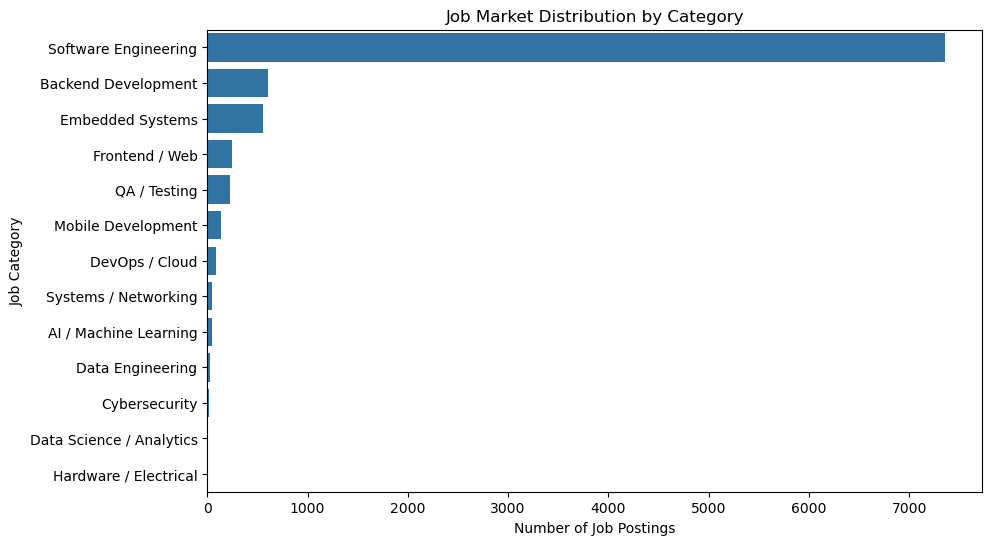

In [65]:
category_counts = df["job_category"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Job Market Distribution by Category")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")

plt.show()

## ML (Machine Learning)

In [66]:
print(df.shape)
print(df.columns.tolist())

print("\nFirst 3 skill values:")
print(df["skills_list"].head(3))

print("\nType of skills_list:")
print(type(df["skills_list"].iloc[0]))

(9380, 14)
['job_title', 'company', 'job_location', 'job_link', 'first_seen', 'search_city', 'search_country', 'job level', 'job_type', 'job_summary', 'job_skills', 'skills_clean', 'skills_list', 'job_category']

First 3 skill values:
0    [c#,  .net,  wpf,  asp.net mvc,  webapi,  c++,...
1    [software implementation,  software testing,  ...
2    [java,  python,  sql,  node.js,  go,  scala,  ...
Name: skills_list, dtype: object

Type of skills_list:
<class 'list'>


In [67]:
model_df = df[["skills_list", "job_category"]].copy()

model_df["skills_text"] = model_df["skills_list"].apply(
    lambda x: " ".join(map(str, x)) if isinstance(x, list) else ""
)

model_df.head()

,skills_list,job_category,skills_text
0,"[c#, .net, wpf, asp.net mvc, webapi, c++,...",Software Engineering,c# .net wpf asp.net mvc webapi c++ progr...
1,"[software implementation, software testing, ...",Software Engineering,software implementation software testing sof...
2,"[java, python, sql, node.js, go, scala, ...",Backend Development,java python sql node.js go scala aws gc...
3,"[javascript, java, typescript, sql, python...",Software Engineering,javascript java typescript sql python go ...
4,"[javascript, java, aws, vue.js, html/css, ...",Software Engineering,javascript java aws vue.js html/css types...


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=1000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(model_df["skills_text"])

print("X shape:", X.shape)

X shape: (9380, 1000)


In [69]:
y = model_df["job_category"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget categories:")
print(y.value_counts())

X shape: (9380, 1000)
y shape: (9380,)

Target categories:
job_category
Software Engineering        7360
Backend Development          605
Embedded Systems             558
Frontend / Web               245
QA / Testing                 227
Mobile Development           139
DevOps / Cloud                83
Systems / Networking          49
AI / Machine Learning         45
Data Engineering              32
Cybersecurity                 22
Data Science / Analytics      10
Hardware / Electrical          5
Name: count, dtype: int64


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (7504, 1000)
Testing data: (1876, 1000)
Training labels: (7504,)
Testing labels: (1876,)


In [71]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [72]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed!
First 10 predictions:
['Software Engineering' 'Software Engineering' 'Software Engineering'
 'Software Engineering' 'Software Engineering' 'Backend Development'
 'Embedded Systems' 'QA / Testing' 'QA / Testing' 'Backend Development']


In [73]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", round(accuracy * 100, 2))

Accuracy: 0.6657782515991472
Accuracy (%): 66.58


In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

                          precision    recall  f1-score   support

   AI / Machine Learning       0.09      0.67      0.16         9
     Backend Development       0.42      0.73      0.53       121
           Cybersecurity       0.43      0.75      0.55         4
        Data Engineering       0.08      0.50      0.14         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.24      0.59      0.34        17
        Embedded Systems       0.47      0.89      0.62       112
          Frontend / Web       0.29      0.82      0.43        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.50      0.89      0.64        28
            QA / Testing       0.38      0.82      0.52        45
    Software Engineering       0.95      0.63      0.76      1472
    Systems / Networking       0.27      0.70      0.39        10

                accuracy                           0.67      1876
        

In [75]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("Linear SVM training completed!")

Linear SVM training completed!


In [76]:
y_pred_svm = svm_model.predict(X_test)

print("SVM predictions completed!")
print("First 10 predictions:")
print(y_pred_svm[:10])

SVM predictions completed!
First 10 predictions:
['Software Engineering' 'Software Engineering' 'Software Engineering'
 'Software Engineering' 'Software Engineering' 'Backend Development'
 'Embedded Systems' 'QA / Testing' 'QA / Testing' 'Software Engineering']


In [77]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", round(svm_accuracy * 100, 2))

SVM Accuracy: 0.8059701492537313
SVM Accuracy (%): 80.6


In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm, zero_division=0))

                          precision    recall  f1-score   support

   AI / Machine Learning       0.21      0.33      0.26         9
     Backend Development       0.58      0.63      0.61       121
           Cybersecurity       0.50      0.75      0.60         4
        Data Engineering       0.07      0.17      0.10         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.45      0.29      0.36        17
        Embedded Systems       0.60      0.79      0.68       112
          Frontend / Web       0.42      0.63      0.51        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.53      0.82      0.65        28
            QA / Testing       0.48      0.67      0.56        45
    Software Engineering       0.91      0.85      0.88      1472
    Systems / Networking       0.58      0.70      0.64        10

                accuracy                           0.81      1876
        

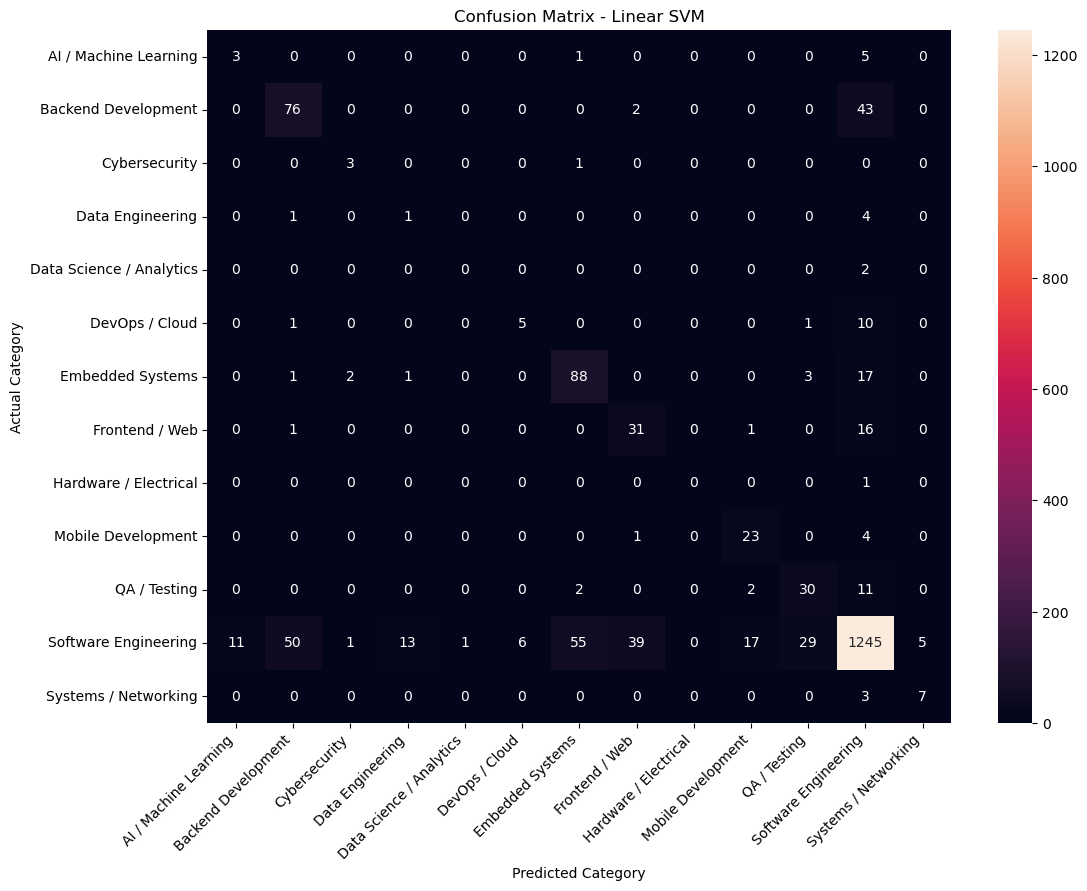

In [79]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [80]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes training completed!")

Naive Bayes training completed!


In [81]:
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes predictions completed!")
print("First 10 predictions:")
print(y_pred_nb[:10])

Naive Bayes predictions completed!
First 10 predictions:
['Software Engineering' 'Software Engineering' 'Software Engineering'
 'Software Engineering' 'Software Engineering' 'Software Engineering'
 'Embedded Systems' 'Software Engineering' 'QA / Testing'
 'Software Engineering']


In [82]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Accuracy (%):", round(nb_accuracy * 100, 2))

Naive Bayes Accuracy: 0.8139658848614072
Naive Bayes Accuracy (%): 81.4


In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb, zero_division=0))

                          precision    recall  f1-score   support

   AI / Machine Learning       0.00      0.00      0.00         9
     Backend Development       0.68      0.39      0.49       121
           Cybersecurity       0.00      0.00      0.00         4
        Data Engineering       0.00      0.00      0.00         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.00      0.00      0.00        17
        Embedded Systems       0.56      0.71      0.63       112
          Frontend / Web       1.00      0.04      0.08        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.50      0.32      0.39        28
            QA / Testing       0.64      0.20      0.31        45
    Software Engineering       0.85      0.94      0.89      1472
    Systems / Networking       0.00      0.00      0.00        10

                accuracy                           0.81      1876
        

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_text_train, X_text_test, y_train, y_test = train_test_split(
    model_df["skills_text"],
    model_df["job_category"],
    test_size=0.2,
    random_state=42,
    stratify=model_df["job_category"]
)

tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=1000,
    ngram_range=(1, 2)
)

X_train = tfidf.fit_transform(X_text_train)
X_test = tfidf.transform(X_text_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7504, 1000)
Testing data: (1876, 1000)


In [85]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.80863539445629
Macro F1: 0.449515887621461

Classification Report:

                          precision    recall  f1-score   support

   AI / Machine Learning       0.21      0.33      0.26         9
     Backend Development       0.59      0.62      0.60       121
           Cybersecurity       0.50      0.75      0.60         4
        Data Engineering       0.00      0.00      0.00         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.45      0.29      0.36        17
        Embedded Systems       0.58      0.79      0.67       112
          Frontend / Web       0.43      0.63      0.51        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.57      0.86      0.69        28
            QA / Testing       0.53      0.71      0.61        45
    Software Engineering       0.91      0.85      0.88      1472
    Systems / Networking       0.64      0.70      0.67      

C:\Users\ishab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ishab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ishab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Macro F1:", f1_score(y_test, y_pred_log, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.6663113006396588
Macro F1: 0.39025239837026515

Classification Report:

                          precision    recall  f1-score   support

   AI / Machine Learning       0.09      0.67      0.16         9
     Backend Development       0.41      0.72      0.52       121
           Cybersecurity       0.43      0.75      0.55         4
        Data Engineering       0.08      0.50      0.14         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.23      0.59      0.33        17
        Embedded Systems       0.48      0.88      0.62       112
          Frontend / Web       0.29      0.82      0.43        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.50      0.89      0.64        28
            QA / Testing       0.39      0.82      0.52        45
    Software Engineering       0.94      0.63      0.76      1472
    Systems / Networking       0.28      0.70      0.40  

In [87]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Macro F1:", f1_score(y_test, y_pred_nb, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.8139658848614072
Macro F1: 0.21414483267120785

Classification Report:

                          precision    recall  f1-score   support

   AI / Machine Learning       0.00      0.00      0.00         9
     Backend Development       0.68      0.39      0.49       121
           Cybersecurity       0.00      0.00      0.00         4
        Data Engineering       0.00      0.00      0.00         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.00      0.00      0.00        17
        Embedded Systems       0.56      0.71      0.62       112
          Frontend / Web       1.00      0.04      0.08        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.50      0.32      0.39        28
            QA / Testing       0.64      0.20      0.31        45
    Software Engineering       0.85      0.94      0.89      1472
    Systems / Networking       0.00      0.00      0.00  

C:\Users\ishab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ishab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ishab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [88]:
model_comparison = {
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_log, average="macro"),
        f1_score(y_test, y_pred_svm, average="macro"),
        f1_score(y_test, y_pred_nb, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted"),
        f1_score(y_test, y_pred_nb, average="weighted")
    ]
}

comparison_df = pd.DataFrame(model_comparison)

comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.666311,0.390252,0.706809
1,Linear SVM,0.808635,0.449516,0.816774
2,Naive Bayes,0.813966,0.214145,0.782596


In [89]:
def predict_job_category(skills):
    skills_text = " ".join(skills)
    skills_vector = tfidf.transform([skills_text])
    prediction = svm_model.predict(skills_vector)
    
    return prediction[0]

In [98]:
test_cases = {
    "Frontend": ["html", "css", "javascript", "react", "typescript"],
    "Backend": ["python", "django", "flask", "postgresql", "rest api"],
    "DevOps": ["docker", "kubernetes", "terraform", "aws", "jenkins"],
    "Mobile": ["android", "kotlin", "java", "firebase"],
    "QA": ["selenium", "automation testing", "testng", "jira"]
}

for name, skills in test_cases.items():
    prediction = predict_job_category(skills)
    print(f"{name} → {prediction}")

Frontend → Software Engineering
Backend → Software Engineering
DevOps → DevOps / Cloud
Mobile → Mobile Development
QA → QA / Testing


In [90]:
skills = ["python", "pandas", "numpy", "sql"]
predicted_category = predict_job_category(skills)
print("Predicted Job Category:", predicted_category)

Predicted Job Category: Software Engineering


In [91]:
def get_top_categories(skills, top_n=3):
    skills_text = " ".join(skills)
    skills_vector = tfidf.transform([skills_text])
    
    scores = svm_model.decision_function(skills_vector).ravel()
    
    top_indices = scores.argsort()[::-1][:top_n]
    
    results = []
    
    for i in top_indices:
        results.append({
            "Category": svm_model.classes_[i],
            "Score": scores[i]
        })
    
    return pd.DataFrame(results)

In [92]:
skills = ["python", "pandas", "numpy", "sql"]

get_top_categories(skills)

,Category,Score
0,Software Engineering,-0.172214
1,Data Science / Analytics,-0.404003
2,DevOps / Cloud,-0.979821


In [93]:
def hiresense_predict():
    user_input = input("Enter your skills separated by commas: ")
    
    skills = [skill.strip() for skill in user_input.split(",") if skill.strip()]
    
    skills_text = " ".join(skills)
    skills_vector = tfidf.transform([skills_text])
    
    scores = svm_model.decision_function(skills_vector).ravel()
    top_indices = scores.argsort()[::-1][:3]
    
    print("\nHireSense Prediction")
    print("--------------------")
    print("Predicted Job Category:", svm_model.classes_[top_indices[0]])
    
    print("\nTop 3 Matching Categories:")
    
    for rank, i in enumerate(top_indices, start=1):
        print(f"{rank}. {svm_model.classes_[i]} | Score: {scores[i]:.3f}")

In [94]:
hiresense_predict()

Enter your skills separated by commas:  HTML, CSS, JavaScript, React, Bootstrap



HireSense Prediction
--------------------
Predicted Job Category: Software Engineering

Top 3 Matching Categories:
1. Software Engineering | Score: 0.262
2. Frontend / Web | Score: -0.052
3. Hardware / Electrical | Score: -1.068


In [95]:
import joblib

joblib.dump(svm_model, "hiresense_svm_model.pkl")
joblib.dump(tfidf, "hiresense_tfidf.pkl")

print("HireSense model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

HireSense model saved successfully!
TF-IDF vectorizer saved successfully!


In [96]:
frontend_skills = []

for skills in df[df["job_category"] == "Frontend / Web"]["skills_list"]:
    if isinstance(skills, list):
        frontend_skills.extend(skills)

frontend_skill_counts = pd.Series(frontend_skills).value_counts()

frontend_skill_counts.head(20)

 javascript              148
 react                   122
 css                     107
 typescript               98
 html                     94
 angular                  76
 aws                      67
 git                      66
 agile                    61
 python                   49
 node.js                  48
 java                     46
 unit testing             40
javascript                39
 docker                   39
react                     35
 frontend development     35
 jira                     34
 product management       30
 kubernetes               30
Name: count, dtype: int64

In [97]:
software_skills = []

for skills in df[df["job_category"] == "Software Engineering"]["skills_list"]:
    if isinstance(skills, list):
        software_skills.extend(skills)

software_skill_counts = pd.Series(software_skills).value_counts()

software_skill_counts.head(20)

 python                  2210
 javascript              2094
 aws                     1870
 sql                     1802
 java                    1583
 git                     1471
 agile                   1470
 kubernetes              1265
 typescript              1226
 c#                      1218
 react                   1215
 docker                  1166
 c++                      963
java                      946
 linux                    928
 angular                  914
 css                      896
 html                     879
 azure                    805
 software development     794
Name: count, dtype: int64

In [100]:
model_df["combined_text"] = (
    model_df["skills_text"].fillna("") + " " +
    df["job_summary"].fillna("")
)

model_df[["skills_text", "combined_text", "job_category"]].head()

,skills_text,combined_text,job_category
0,c# .net wpf asp.net mvc webapi c++ progr...,c# .net wpf asp.net mvc webapi c++ progr...,Software Engineering
1,software implementation software testing sof...,software implementation software testing sof...,Software Engineering
2,java python sql node.js go scala aws gc...,java python sql node.js go scala aws gc...,Backend Development
3,javascript java typescript sql python go ...,javascript java typescript sql python go ...,Software Engineering
4,javascript java aws vue.js html/css types...,javascript java aws vue.js html/css types...,Software Engineering


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_combined_train, X_combined_test, y_combined_train, y_combined_test = train_test_split(
    model_df["combined_text"],
    model_df["job_category"],
    test_size=0.2,
    random_state=42,
    stratify=model_df["job_category"]
)

tfidf_combined = TfidfVectorizer(
    lowercase=True,
    max_features=3000,
    ngram_range=(1, 2)
)

X_combined_train_vec = tfidf_combined.fit_transform(X_combined_train)
X_combined_test_vec = tfidf_combined.transform(X_combined_test)

print("Training data:", X_combined_train_vec.shape)
print("Testing data:", X_combined_test_vec.shape)

Training data: (7504, 3000)
Testing data: (1876, 3000)


In [102]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

svm_combined = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_combined.fit(
    X_combined_train_vec,
    y_combined_train
)

y_pred_combined = svm_combined.predict(
    X_combined_test_vec
)

print("Accuracy:", accuracy_score(y_combined_test, y_pred_combined))
print("Macro F1:", f1_score(y_combined_test, y_pred_combined, average="macro"))
print("Weighted F1:", f1_score(y_combined_test, y_pred_combined, average="weighted"))

Accuracy: 0.8939232409381663
Macro F1: 0.558295553198492
Weighted F1: 0.8943904123287342


In [103]:
for name, skills in test_cases.items():
    skills_text = " ".join(skills)
    skills_vector = tfidf_combined.transform([skills_text])
    prediction = svm_combined.predict(skills_vector)[0]

    print(f"{name} → {prediction}")

Frontend → Software Engineering
Backend → Software Engineering
DevOps → DevOps / Cloud
Mobile → Mobile Development
QA → QA / Testing


In [105]:
print(classification_report(
    y_combined_test,
    y_pred_combined,
    zero_division=0
))

                          precision    recall  f1-score   support

   AI / Machine Learning       0.38      0.56      0.45         9
     Backend Development       0.82      0.75      0.78       121
           Cybersecurity       0.60      0.75      0.67         4
        Data Engineering       0.20      0.17      0.18         6
Data Science / Analytics       0.00      0.00      0.00         2
          DevOps / Cloud       0.53      0.47      0.50        17
        Embedded Systems       0.78      0.83      0.81       112
          Frontend / Web       0.62      0.69      0.65        49
   Hardware / Electrical       0.00      0.00      0.00         1
      Mobile Development       0.86      0.86      0.86        28
            QA / Testing       0.66      0.87      0.75        45
    Software Engineering       0.94      0.93      0.94      1472
    Systems / Networking       0.64      0.70      0.67        10

                accuracy                           0.89      1876
        

In [106]:
import joblib

joblib.dump(svm_combined, "hiresense_combined_svm.pkl")
joblib.dump(tfidf_combined, "hiresense_combined_tfidf.pkl")

print("Combined model saved successfully!")
print("Combined TF-IDF saved successfully!")

Combined model saved successfully!
Combined TF-IDF saved successfully!
